# Adult Income Prediction — Supervised Models (Day 2)

Continuation of Day 1: build preprocessing pipelines and train Logistic Regression and Decision Tree classifiers on the **same hold-out test set** from Day 1.

**Primary metric:** F1 score (same as Day 1).

## 1. Setup & Data Loading

We reuse the exact Day 1 data source, cleaning (`?` → NaN), target encoding, and train/test split (`random_state=42`, 80/20 stratified).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Same loading as Day 1
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()
df = df.rename(columns={"class": "income"})

# Convert ? (with optional whitespace) to NaN
df = df.replace(r"^\s*\?$", np.nan, regex=True)

# Binary target: <=50K -> 0, >50K -> 1
df["income"] = df["income"].astype(str).map({"<=50K": 0, ">50K": 1})

print("Shape:", df.shape)
print("Positive class rate: {:.2f}%".format(df["income"].mean() * 100))
df.head()

Shape: (48842, 15)
Positive class rate: 23.93%


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [3]:
# Same hold-out split as Day 1
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train size: {len(X_train):,} ({len(X_train) / len(df) * 100:.1f}%)")
print(f"Test size:  {len(X_test):,} ({len(X_test) / len(df) * 100:.1f}%)")
print(f"Train positive rate: {y_train.mean() * 100:.2f}%")
print(f"Test positive rate:  {y_test.mean() * 100:.2f}%")

Train size: 39,073 (80.0%)
Test size:  9,769 (20.0%)
Train positive rate: 23.93%
Test positive rate:  23.93%


## 2. Preprocessing

### Feature types

**Numeric (6):** `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`

**Categorical (8):** `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`

> Note: `education` and `education-num` are correlated. Both are kept for now; redundancy will be tested in Day 3.

In [4]:
numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]

categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
# Numeric: median imputation, then StandardScaler
# Median works better than mean here because capital-gain is skewed.

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical: fill missing with "Missing", then one-hot encode
# handle_unknown="ignore" avoids errors if a new category appears in test data

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Pipelines and leakage

Imputers and scalers are fit on the training set only. Putting preprocessing inside the pipeline stops test data from leaking into those steps.

## 3. Train Models

Fit both models on the **training set only**. The hold-out test set is not touched until evaluation.

In [6]:
log_reg_pipe = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="lbfgs",  # supports L2 regularization (default penalty)
        max_iter=1000,
    )),
])

dt_pipe = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

log_reg_pipe.fit(X_train, y_train)
dt_pipe.fit(X_train, y_train)

print("Both models fitted on training set only.")

Both models fitted on training set only.


## 4. Evaluation on Hold-Out Test

Compute accuracy, precision, recall, F1, ROC AUC, and PR AUC. Compare against Day 1 baselines.

In [7]:
def evaluate_model(y_true, y_pred, y_score):
    """Return accuracy, precision, recall, F1, ROC AUC, and PR AUC."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
        "PR AUC": average_precision_score(y_true, y_score),
    }


def get_results(pipe, name):
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]
    return evaluate_model(y_test, y_pred, y_score)


# Day 1 baseline numbers (same hold-out test)
day1_baselines = pd.DataFrame(
    [
        {
            "Accuracy": 0.7607,
            "Precision": 0.0000,
            "Recall": 0.0000,
            "F1": 0.0000,
            "ROC AUC": 0.5000,
            "PR AUC": 0.2393,
        },
        {
            "Accuracy": 0.7530,
            "Precision": 0.4844,
            "Recall": 0.4970,
            "F1": 0.4906,
            "ROC AUC": 0.6653,
            "PR AUC": 0.3611,
        },
    ],
    index=["Majority Baseline (Day 1)", "Education Rule (Day 1)"],
)

model_results = pd.DataFrame(
    [
        get_results(log_reg_pipe, "Logistic Regression"),
        get_results(dt_pipe, "Decision Tree"),
    ],
    index=["Logistic Regression", "Decision Tree"],
)

comparison = pd.concat([day1_baselines, model_results])
comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Baseline (Day 1),0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Education Rule (Day 1),0.7530,0.4844,0.4970,0.4906,0.6653,0.3611
Logistic Regression,0.8543,0.7427,0.5988,0.6630,0.9057,0.7670
Decision Tree,0.8186,0.6185,0.6317,0.6251,0.7546,0.4789


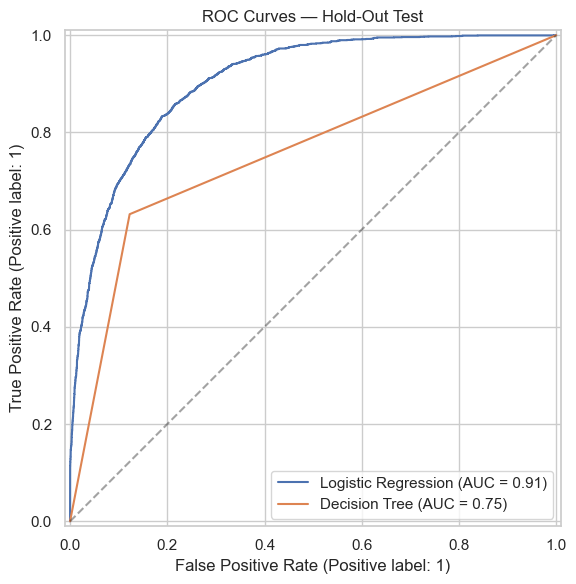

In [8]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(log_reg_pipe, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(dt_pipe, X_test, y_test, ax=ax, name="Decision Tree")
ax.set_title("ROC Curves — Hold-Out Test")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.tight_layout()
plt.show()

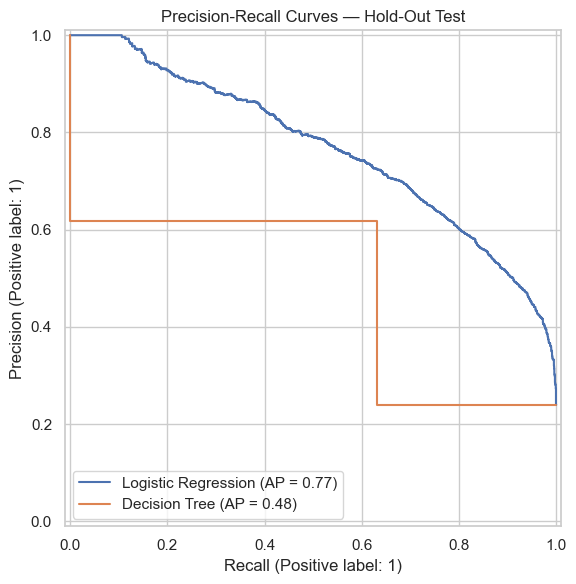

In [9]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_estimator(log_reg_pipe, X_test, y_test, ax=ax, name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(dt_pipe, X_test, y_test, ax=ax, name="Decision Tree")
ax.set_title("Precision-Recall Curves — Hold-Out Test")
plt.tight_layout()
plt.show()

=== Logistic Regression ===
False Positives: 485 | False Negatives: 938
→ More false negatives: recall suffers more.

=== Decision Tree ===
False Positives: 911 | False Negatives: 861
→ More false positives: precision suffers more.



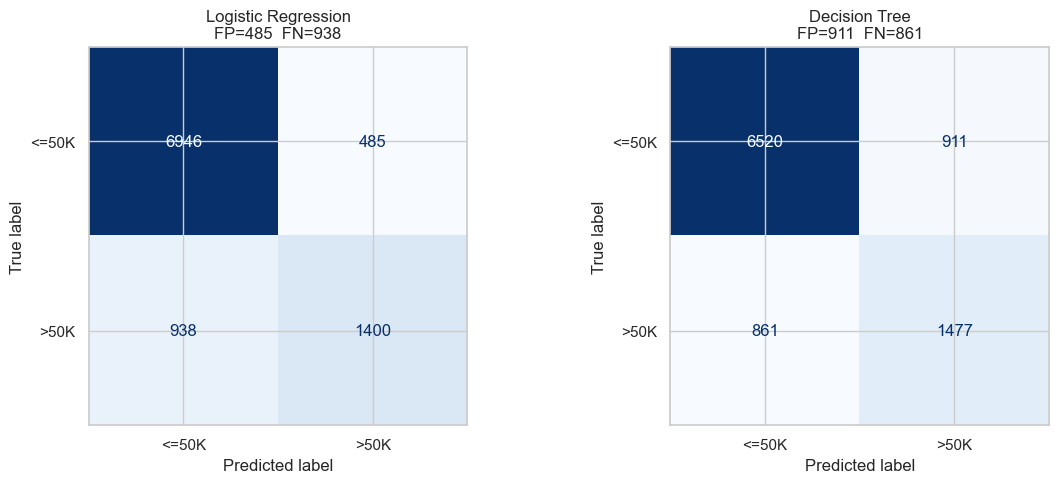

In [10]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pipe, title in zip(
    axes,
    [log_reg_pipe, dt_pipe],
    ["Logistic Regression", "Decision Tree"],
):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{title}\nFP={fp:,}  FN={fn:,}")
    print(f"=== {title} ===")
    print(f"False Positives: {fp:,} | False Negatives: {fn:,}")
    if fp > fn:
        print("→ More false positives: precision suffers more.")
    elif fn > fp:
        print("→ More false negatives: recall suffers more.")
    else:
        print("→ FP and FN are equal.")
    print()

plt.tight_layout()
plt.show()

### F1 and error types

Our primary metric is F1, which looks at both precision and recall. For Logistic Regression, false negatives (938) were higher than false positives (485), so recall was the weaker side — similar to what we saw with the education rule in Day 1.

## 5. Interpretability

### Logistic Regression — Top coefficients

Positive coefficients push the model toward predicting >50K; negative ones push toward <=50K.

In [11]:
feature_names = log_reg_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = log_reg_pipe.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})

print("=== Top 10 Positive Coefficients ===")
top_pos = coef_df.nlargest(10, "coefficient")
display(top_pos)

print("\n=== Top 10 Negative Coefficients ===")
top_neg = coef_df.nsmallest(10, "coefficient")
display(top_neg)

=== Top 10 Positive Coefficients ===


,feature,coefficient
3,num__capital-gain,2.258608
33,cat__marital-status_Married-civ-spouse,1.566532
32,cat__marital-status_Married-AF-spouse,1.318724
75,cat__native-country_France,0.884161
41,cat__occupation_Exec-managerial,0.837905
58,cat__relationship_Wife,0.790203
74,cat__native-country_England,0.772480
86,cat__native-country_Ireland,0.726662
2,num__education-num,0.698305
66,cat__native-country_Cambodia,0.686153



=== Top 10 Negative Coefficients ===


,feature,coefficient
69,cat__native-country_Columbia,-1.374777
47,cat__occupation_Priv-house-serv,-1.323425
35,cat__marital-status_Never-married,-1.250144
101,cat__native-country_South,-1.002472
64,cat__sex_Female,-0.926922
42,cat__occupation_Farming-fishing,-0.907103
55,cat__relationship_Other-relative,-0.889425
71,cat__native-country_Dominican-Republic,-0.860532
46,cat__occupation_Other-service,-0.860058
56,cat__relationship_Own-child,-0.795329


**Coefficient takeaways:** `capital-gain` and `education-num` have the strongest positive effects. `Married-civ-spouse` and `Exec-managerial` also push predictions toward >50K. On the negative side, `Never-married`, `Own-child`, `Other-service`, and `sex_Female` pull predictions toward <=50K. These patterns line up with the Day 1 error analysis — education alone is not enough without occupation and marital status.

### 5b. Decision Tree — Depth and top splits

In [12]:
dt_clf = dt_pipe.named_steps["clf"]

train_acc = dt_pipe.score(X_train, y_train)
test_acc = dt_pipe.score(X_test, y_test)

print(f"Tree depth:       {dt_clf.get_depth()}")
print(f"Number of leaves: {dt_clf.get_n_leaves()}")
print(f"Train accuracy:   {train_acc:.4f}")
print(f"Test accuracy:    {test_acc:.4f}")
print(f"Train - Test gap: {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print("\nLarge train/test gap — likely overfitting.")

Tree depth:       68
Number of leaves: 5668
Train accuracy:   0.9999
Test accuracy:    0.8186
Train - Test gap: 0.1813

Large train/test gap — likely overfitting.


In [13]:
# Top 3 splits (tree uses preprocessed features; numeric thresholds are on scaled scale)
tree = dt_clf.tree_
feat_names = list(feature_names)

def describe_split(node_id):
    feat_idx = tree.feature[node_id]
    if feat_idx < 0:
        return None
    return {
        "node": node_id,
        "feature": feat_names[feat_idx],
        "threshold": tree.threshold[node_id],
    }

print("=== Top 3 Splits (root and first two internal nodes) ===")
for node_id in range(3):
    info = describe_split(node_id)
    if info:
        print(f"Split {node_id + 1}: {info['feature']} <= {info['threshold']:.4f}")

print("\nTree logic (first levels via export_text):")
print(export_text(dt_clf, feature_names=feat_names, max_depth=3))

=== Top 3 Splits (root and first two internal nodes) ===
Split 1: cat__marital-status_Married-civ-spouse <= 0.5000
Split 2: num__capital-gain <= 0.8180
Split 3: num__education-num <= 0.9405

Tree logic (first levels via export_text):
|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 0.94
|   |   |   |--- num__capital-loss <= 5.21
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- num__capital-loss >  5.21
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- num__education-num >  0.94
|   |   |   |--- num__age <= -0.52
|   |   |   |   |--- truncated branch of depth 28
|   |   |   |--- num__age >  -0.52
|   |   |   |   |--- truncated branch of depth 28
|   |--- num__capital-gain >  0.82
|   |   |--- num__age <= -1.32
|   |   |   |--- num__capital-gain <= 3.14
|   |   |   |   |--- class: 1
|   |   |   |--- num__capital-gain >  3.14
|   |   |   |   |--- class: 0
|   |   |--- num__age >  -1.32
|

The first splits use marital status, capital-gain, and education-num, which all make sense for income. The tree still overfits — depth 68 and train accuracy near 100% while test accuracy is 0.82.

## 6. Model Selection for Day 3

In [14]:
# Save preprocessing + model pipeline for reuse
joblib.dump(log_reg_pipe, "log_reg_pipeline.joblib")
joblib.dump(log_reg_pipe.named_steps["preprocess"], "preprocessor.joblib")
print("Saved log_reg_pipeline.joblib and preprocessor.joblib")

Saved log_reg_pipeline.joblib and preprocessor.joblib


### Conclusion

Logistic Regression performed best on the hold-out test (F1 = 0.6630) and did not overfit like the tree. I will continue with logistic regression in Day 3 and try a validation split, `class_weight='balanced'`, and dropping redundant education features.